<a href="https://colab.research.google.com/github/Shirisha-ts-07/Shirisha-ts-07/blob/main/Market_Basket_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


🔹 FREQUENT ITEMSETS (min_support=0.6):
      itemsets_str  support
              milk      1.0
             bread      1.0
             apple      0.6
       bread, milk      1.0
       apple, milk      0.6
      apple, bread      0.6
apple, bread, milk      0.6

🔹 ASSOCIATION RULES (lift ≥ 1.0):
antecedents_str consequents_str  support  confidence  lift
           milk           apple      0.6         0.6   1.0
          bread           apple      0.6         0.6   1.0
    bread, milk           apple      0.6         0.6   1.0
           milk    apple, bread      0.6         0.6   1.0
          bread     apple, milk      0.6         0.6   1.0


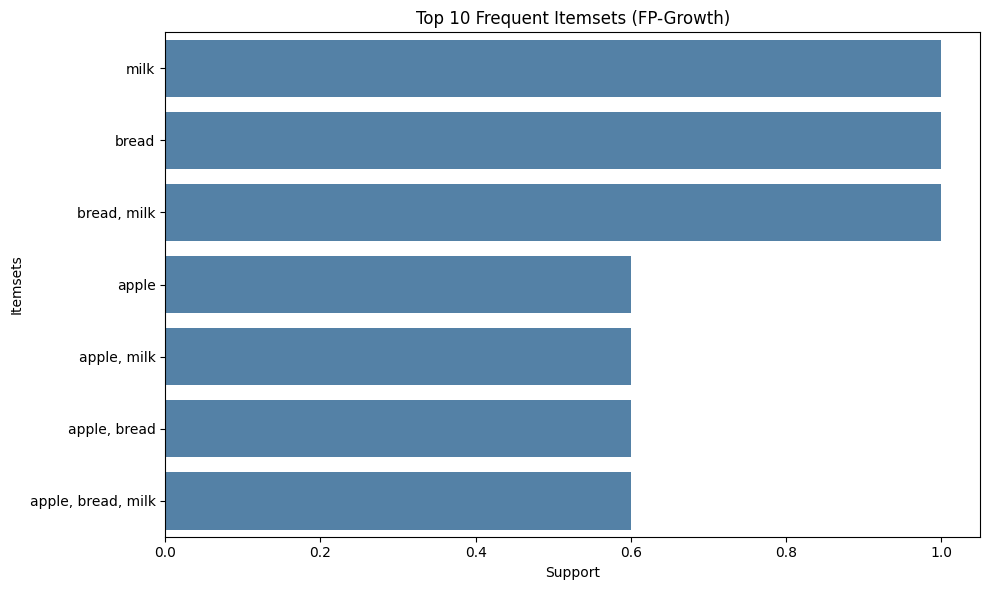

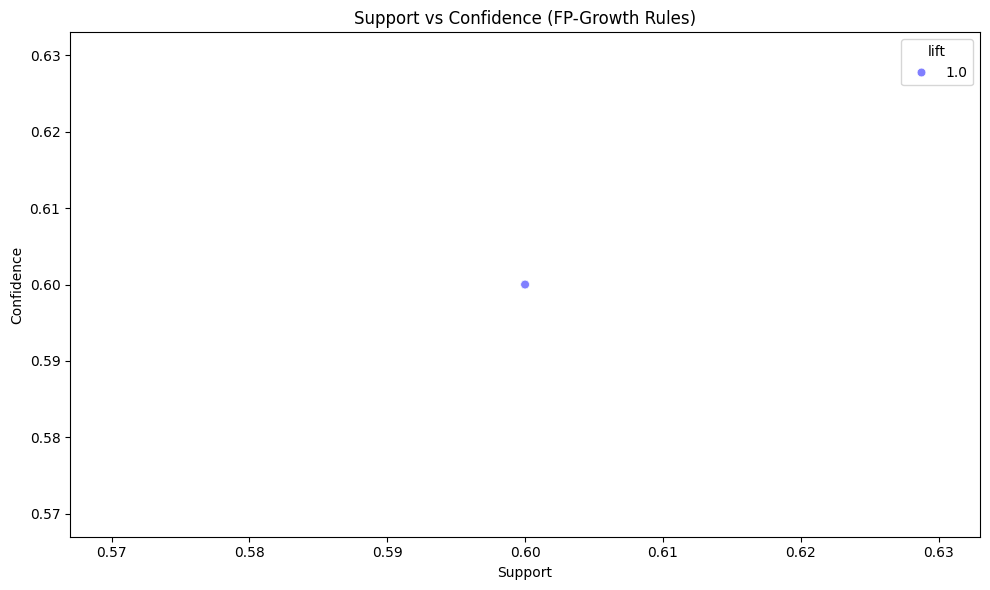

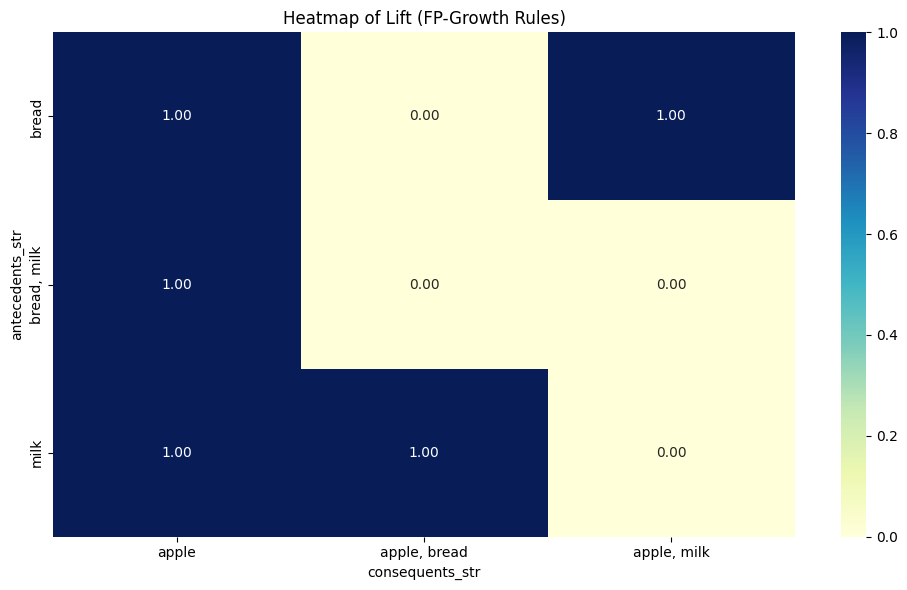

<ipython-input-1-1eed46cd0cc7>:88: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


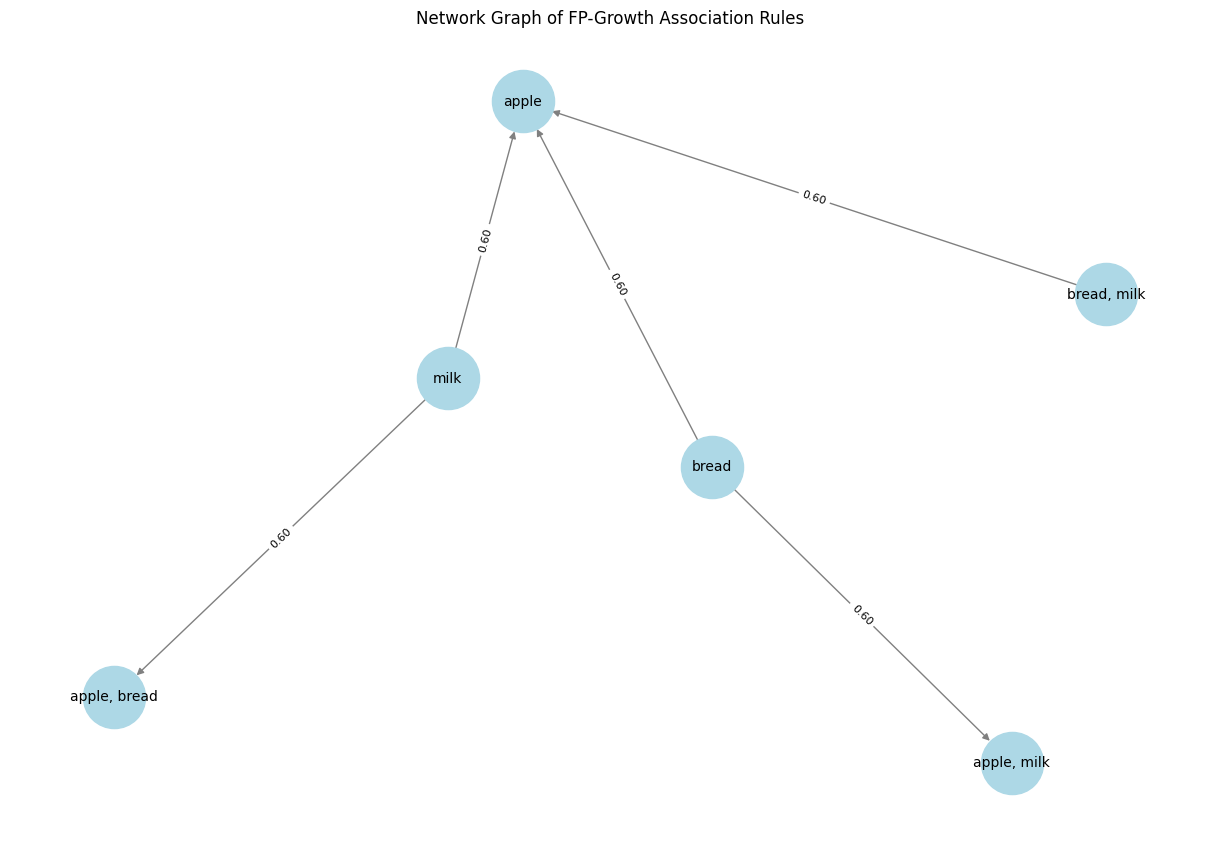

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.frequent_patterns import fpgrowth, association_rules
from mlxtend.preprocessing import TransactionEncoder
import networkx as nx
import warnings

warnings.filterwarnings("ignore", category=RuntimeWarning)

# Sample dataset
dataset = [
    ['milk', 'bread', 'nuts', 'apple'],
    ['milk', 'bread', 'nuts'],
    ['milk', 'bread'],
    ['milk', 'bread', 'apple'],
    ['milk', 'bread', 'apple']
]

# Transform to one-hot encoded format
te = TransactionEncoder()
te_ary = te.fit(dataset).transform(dataset)
df = pd.DataFrame(te_ary, columns=te.columns_)

# Frequent itemsets using FP-Growth
frequent_itemsets = fpgrowth(df, min_support=0.6, use_colnames=True)

# Generate association rules
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.0)
rules.replace([np.inf, -np.inf], np.nan, inplace=True)
rules.dropna(inplace=True)

# Create readable string versions
frequent_itemsets['itemsets_str'] = frequent_itemsets['itemsets'].apply(lambda x: ', '.join(sorted(x)))
rules['antecedents_str'] = rules['antecedents'].apply(lambda x: ', '.join(sorted(x)))
rules['consequents_str'] = rules['consequents'].apply(lambda x: ', '.join(sorted(x)))

# Show results in terminal
print("\n🔹 FREQUENT ITEMSETS (min_support=0.6):")
print(frequent_itemsets[['itemsets_str', 'support']].to_string(index=False))

print("\n🔹 ASSOCIATION RULES (lift ≥ 1.0):")
print(rules[['antecedents_str', 'consequents_str', 'support', 'confidence', 'lift']].to_string(index=False))

# Bar plot for frequent itemsets
plt.figure(figsize=(10, 6))
top_items = frequent_itemsets.sort_values('support', ascending=False).head(10)
sns.barplot(x='support', y='itemsets_str', data=top_items, color='steelblue')
plt.title('Top 10 Frequent Itemsets (FP-Growth)')
plt.xlabel('Support')
plt.ylabel('Itemsets')
plt.tight_layout()
plt.show()

# Scatter plot: Support vs Confidence
plt.figure(figsize=(10, 6))
sns.scatterplot(data=rules, x='support', y='confidence', size='lift', hue='lift',
                palette='cool', sizes=(40, 400), legend='brief')
plt.title('Support vs Confidence (FP-Growth Rules)')
plt.xlabel('Support')
plt.ylabel('Confidence')
plt.tight_layout()
plt.show()

# Heatmap of Lift
pivot = rules.pivot_table(index='antecedents_str', columns='consequents_str',
                          values='lift', fill_value=0)
plt.figure(figsize=(10, 6))
sns.heatmap(pivot, annot=True, cmap='YlGnBu', fmt=".2f")
plt.title('Heatmap of Lift (FP-Growth Rules)')
plt.tight_layout()
plt.show()

# Network Graph of Association Rules
G = nx.DiGraph()
for _, row in rules.iterrows():
    G.add_edge(row['antecedents_str'], row['consequents_str'],
               weight=row['lift'], label=f"{row['confidence']:.2f}")

plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G, k=1)
nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=2000,
        font_size=10, edge_color='gray', arrows=True)
edge_labels = nx.get_edge_attributes(G, 'label')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8)
plt.title("Network Graph of FP-Growth Association Rules")
plt.tight_layout()
plt.show()
